# Main 19-Site Weighted-RVB + Heisenberg-HVA Result

This notebook is the clean presentation path. It reads the reproducible outputs generated by `run_all.ps1` / `run_all.sh` and shows the finite-size 19-site Kagome result without rerunning long optimizations.

**Main claim:** On the 19-site Kagome Heisenberg benchmark, a classically optimized signed weighted-RVB state over 54 maximum dimer coverings reaches `E=-29.0121`, `F=0.9785`. Shallow edge-colored Heisenberg-HVA refinement improves this to `E=-29.0376`, `F=0.9825` at `p=4`, without Hamiltonian calibration. This is finite-size evidence, not scalable QSL preparation.

Small group, bond, and triangle exact calibrated-Hamiltonian references currently reach closer energy and fidelity than the no-calibration p=4 baseline. The no-calibration p=4 HVA result is strong but does not outperform the best small calibrated-Hamiltonian exact reference. The calibration scan is an exact-state diagnostic, not a hardware-preparable circuit.

The original Ahsan Kagome-VQE notebook is treated as provenance and methodology context for the 19-site connectivity, hardware-efficient VQE setup, and calibrated-Hamiltonian/defect-triangle strategy. It is not used as a direct replacement for this weighted-RVB + Heisenberg-HVA workflow.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

PROJECT = Path.cwd()
if PROJECT.name == "notebooks":
    PROJECT = PROJECT.parent

RESULTS = PROJECT / "results"
FIGURES = PROJECT / "figures"
plt.rcParams["figure.dpi"] = 130

## Final Result Table

In [2]:
final = pd.read_csv(RESULTS / "final_result_table.csv")
final[[
    "state",
    "energy_unscaled_pauli",
    "error_vs_exact",
    "energy_physical_spin",
    "fidelity",
    "gap_closed_vs_static_percent",
    "entropy_midcut",
    "max_magnetization",
    "af_weight_participation",
]]

,state,energy_unscaled_pauli,error_vs_exact,energy_physical_spin,fidelity,gap_closed_vs_static_percent,entropy_midcut,max_magnetization,af_weight_participation
0,Static dimer,-27.000000,2.146168e+00,-6.750000,0.014241,0.000000,1.000000,0.500000,9.000000
1,Equal RVB-54,-26.397813,2.748355e+00,-6.599453,0.004371,-28.058703,3.366154,0.129849,21.869594
2,Weighted RVB-54,-29.012072,1.340960e-01,-7.253018,0.978536,93.751840,3.129502,0.107755,20.429003
3,Weighted RVB + HVA p=1,-29.023026,1.231418e-01,-7.255757,0.979995,94.262246,3.129583,0.107529,20.405928
4,Weighted RVB + HVA p=2,-29.036332,1.098363e-01,-7.259083,0.982446,94.882214,3.140691,0.107710,20.433531
5,Weighted RVB + HVA p=3,-29.037494,1.086741e-01,-7.259373,0.982442,94.936364,3.141921,0.106811,20.442665
6,Weighted RVB + HVA p=4,-29.037601,1.085668e-01,-7.259400,0.982518,94.941367,3.155489,0.105490,20.443456
7,Exact,-29.146168,4.263256e-14,-7.286542,1.000000,100.000000,3.212669,0.094007,20.460732


## Depth Improvement

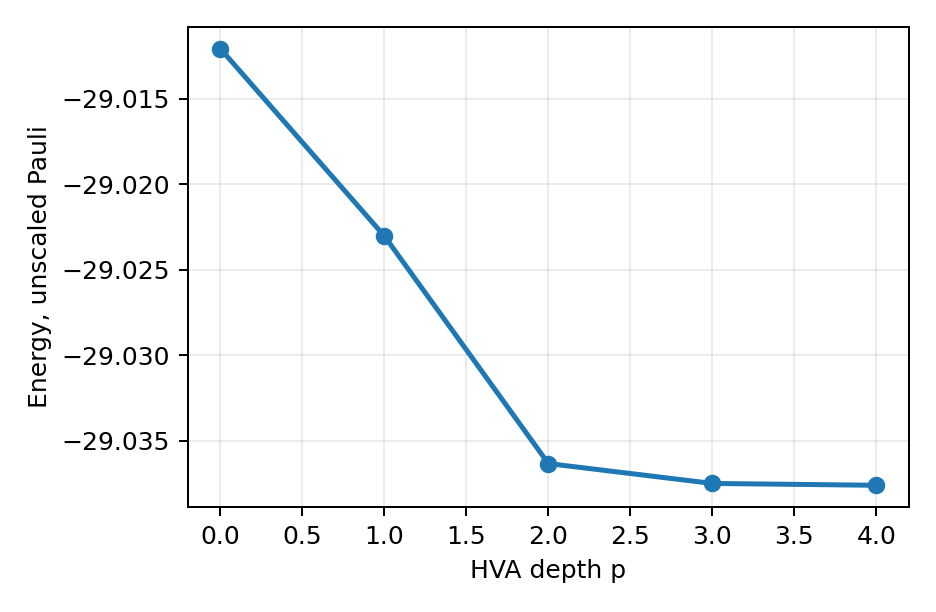

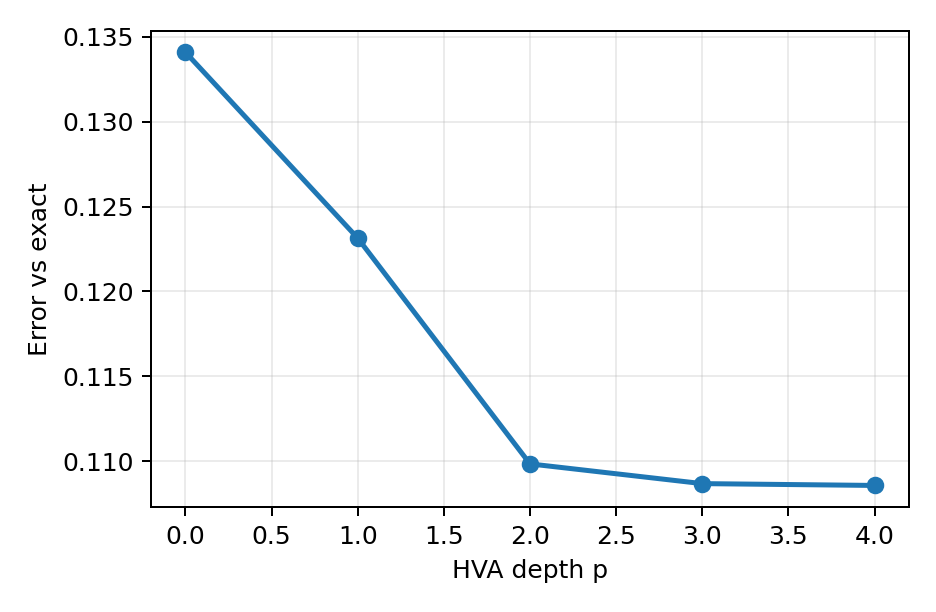

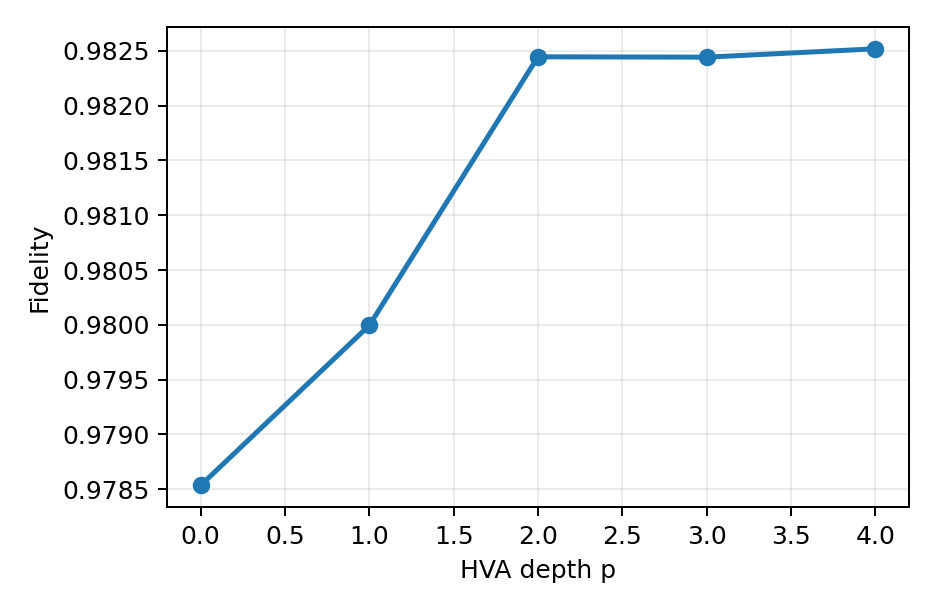

In [3]:
for name in [
    "depth/energy_vs_hva_depth.png",
    "depth/error_vs_hva_depth.png",
    "depth/fidelity_vs_hva_depth.png",
]:
    display(Image(filename=str(FIGURES / name)))

## Bond-Correlation Maps

Layout is graph-theoretic for visualization; it is not a physical embedding of the Kagome patch.

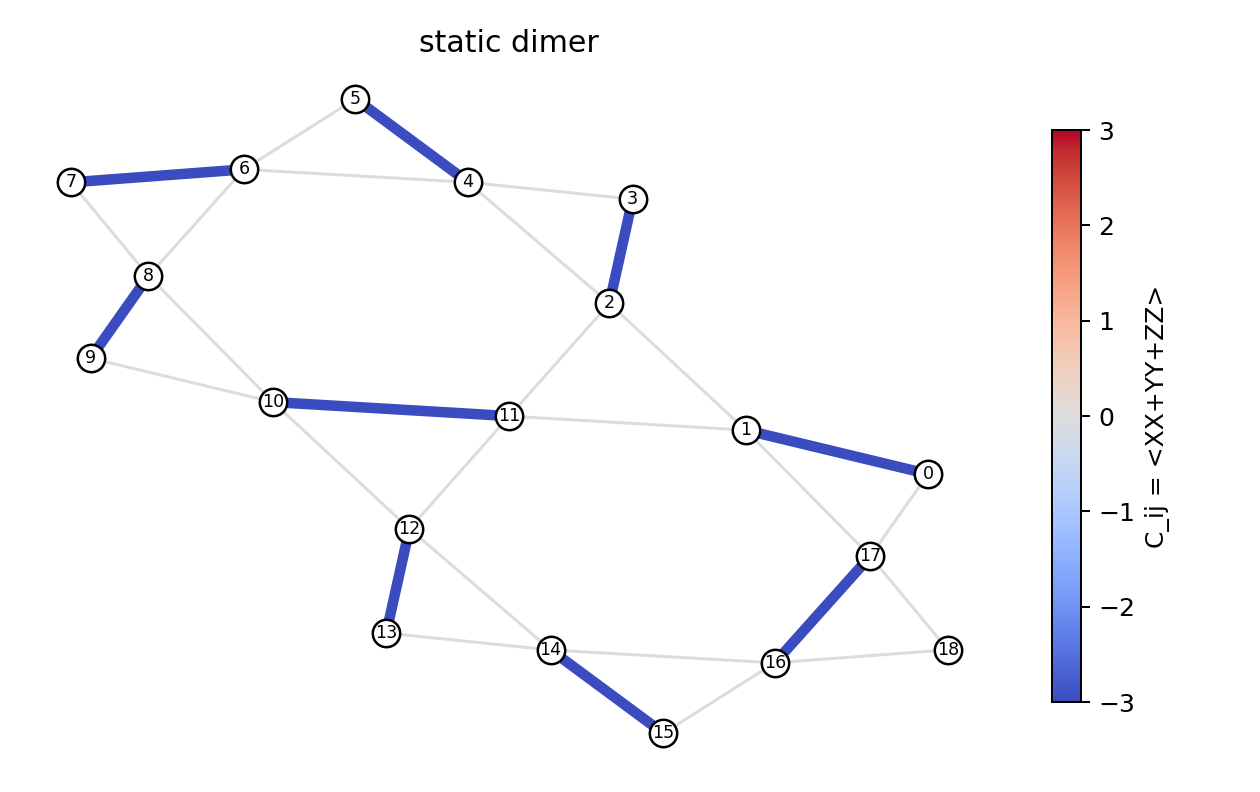

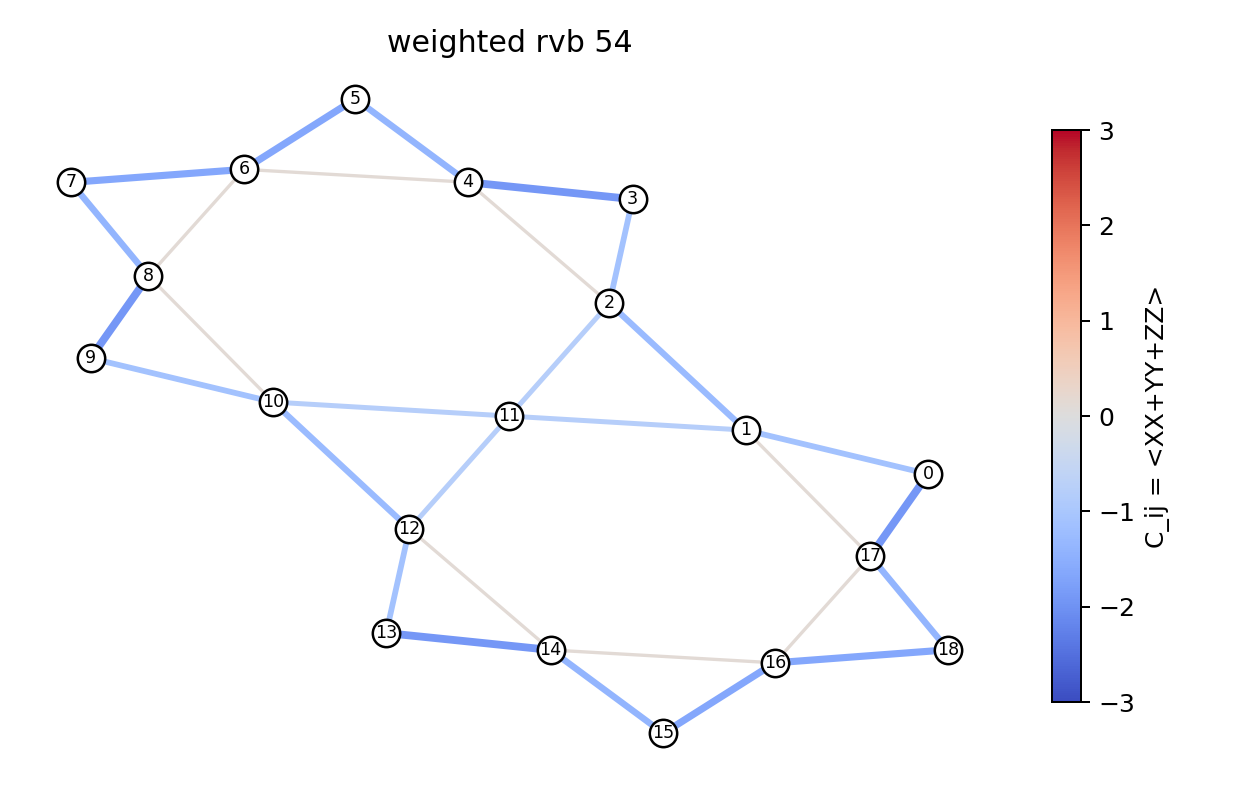

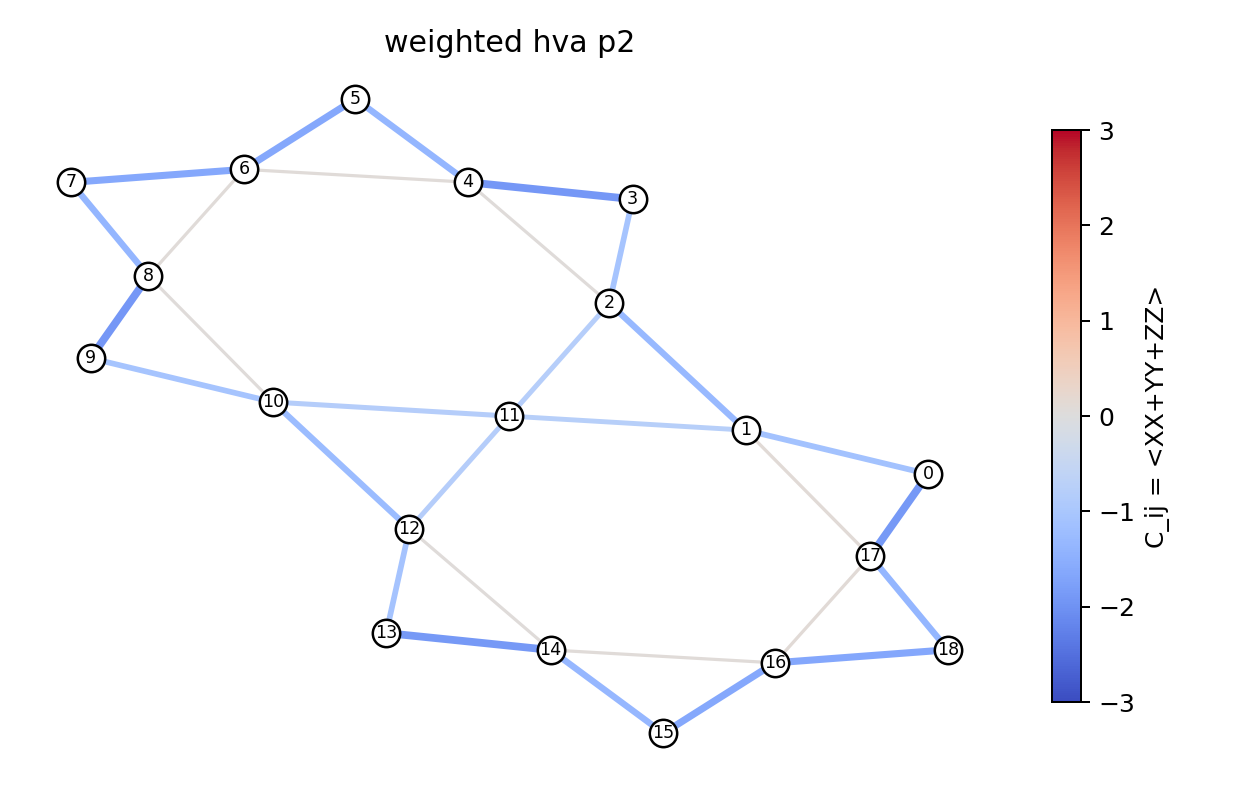

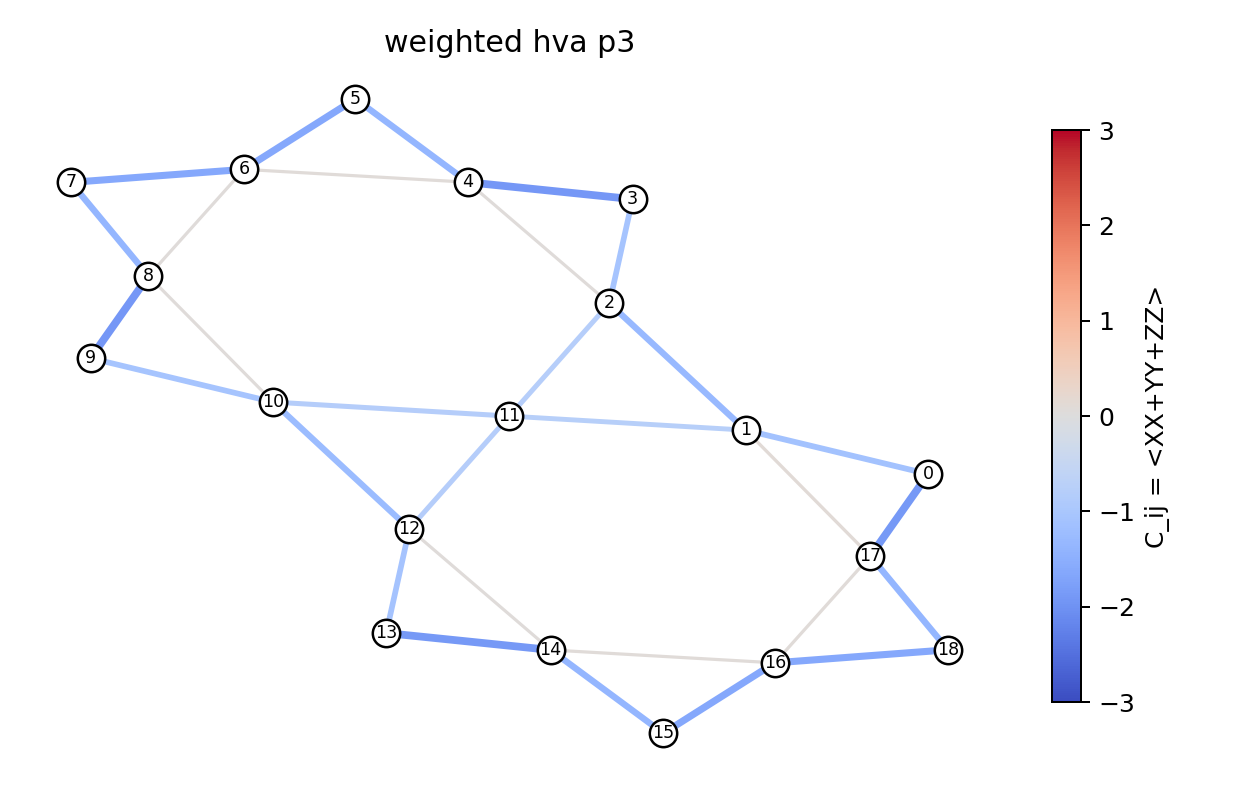

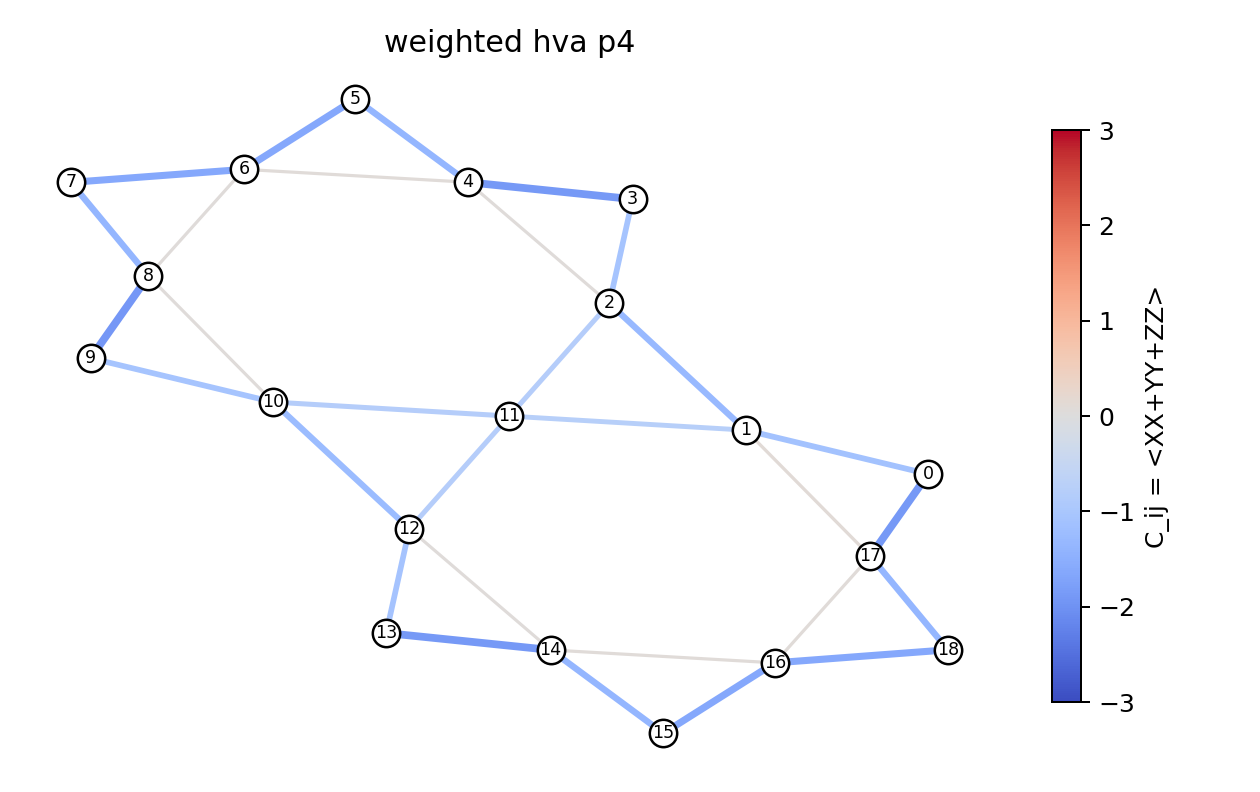

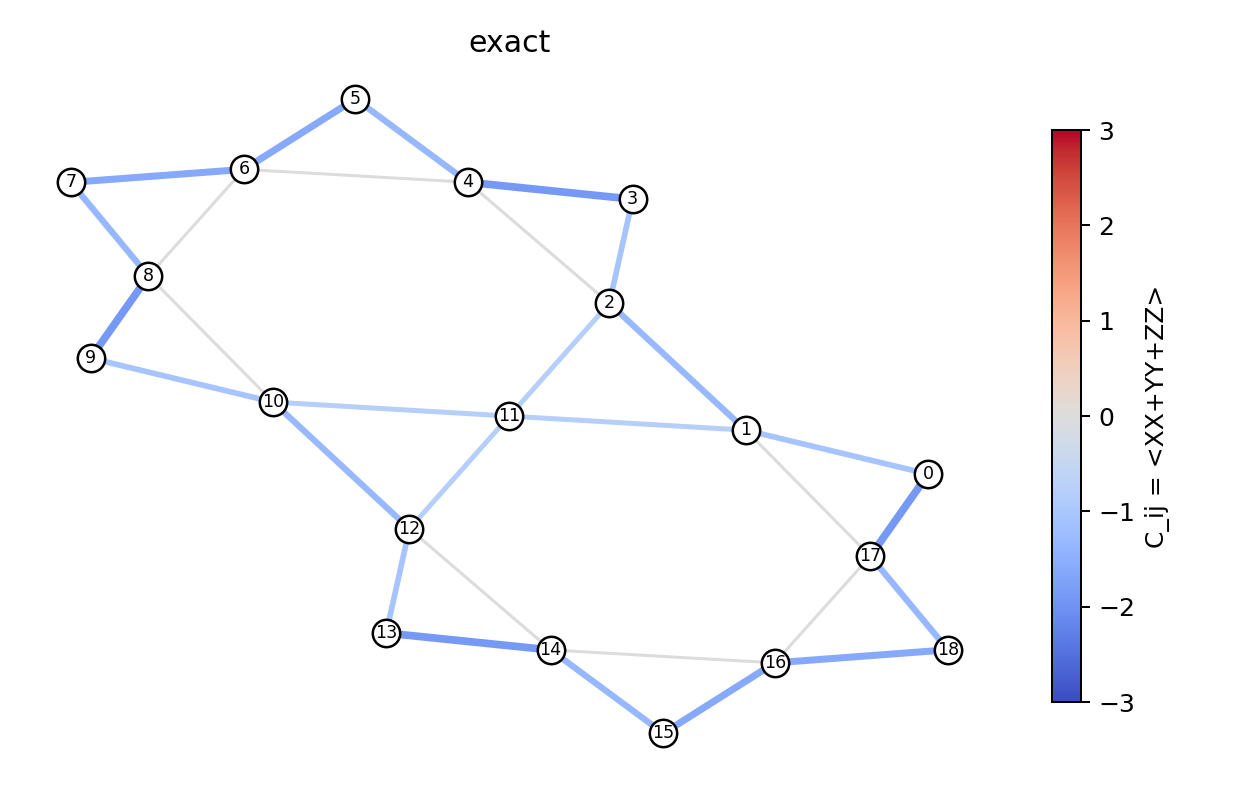

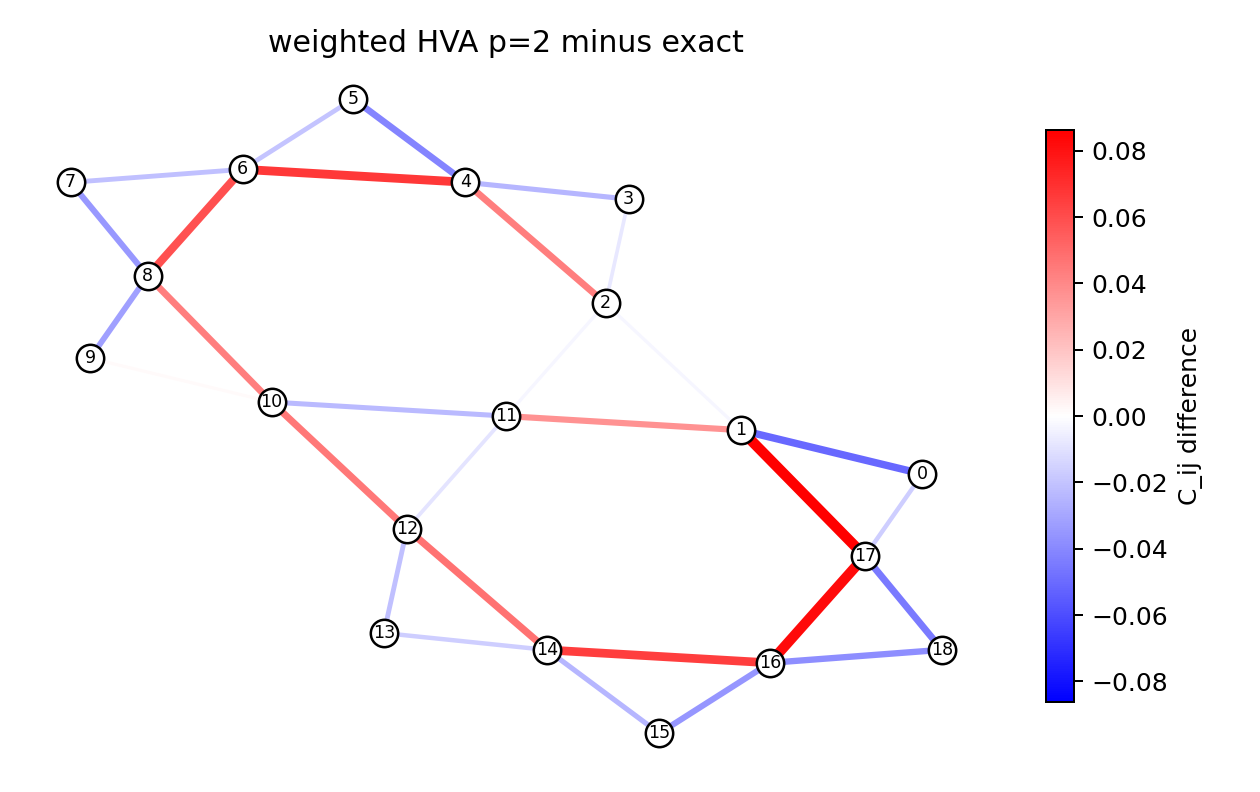

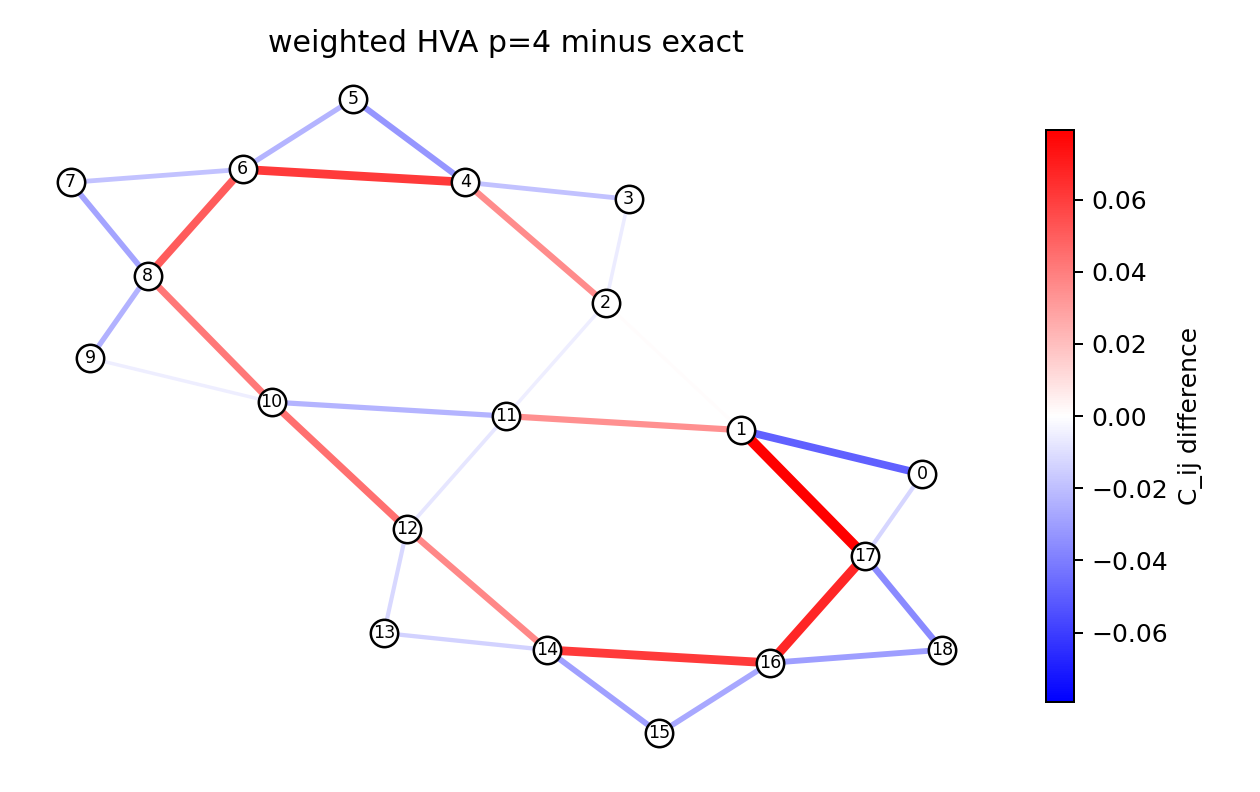

In [4]:
for name in [
    "bond_maps/bond_map_static_dimer.png",
    "bond_maps/bond_map_weighted_rvb.png",
    "bond_maps/bond_map_weighted_hva_p2.png",
    "bond_maps/bond_map_weighted_hva_p3.png",
    "bond_maps/bond_map_weighted_hva_p4.png",
    "bond_maps/bond_map_exact.png",
    "bond_maps/bond_map_error_p2_vs_exact.png",
    "bond_maps/bond_map_error_best_hva_vs_exact.png",
]:
    path = FIGURES / name
    if path.exists():
        display(Image(filename=str(path)))

## Calibration Energy-Fidelity Tradeoff

The calibration points are exact ground states of modified Hamiltonians evaluated against the original Hamiltonian. They are reference states, not direct hardware-efficient preparation circuits. The no-calibration HVA route remains the circuit-compatible refinement baseline.

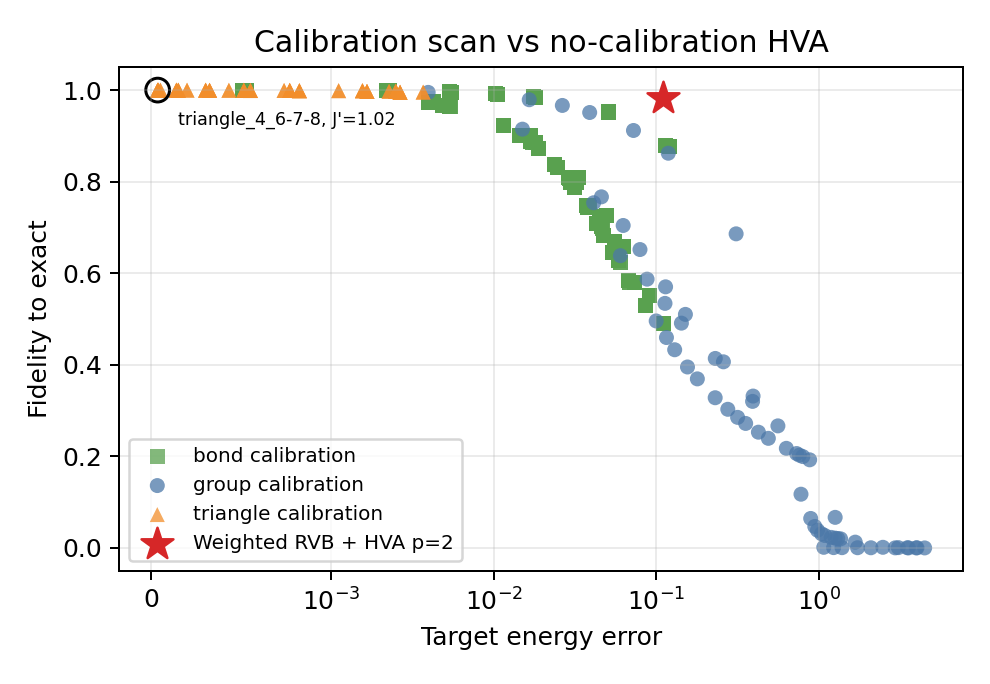

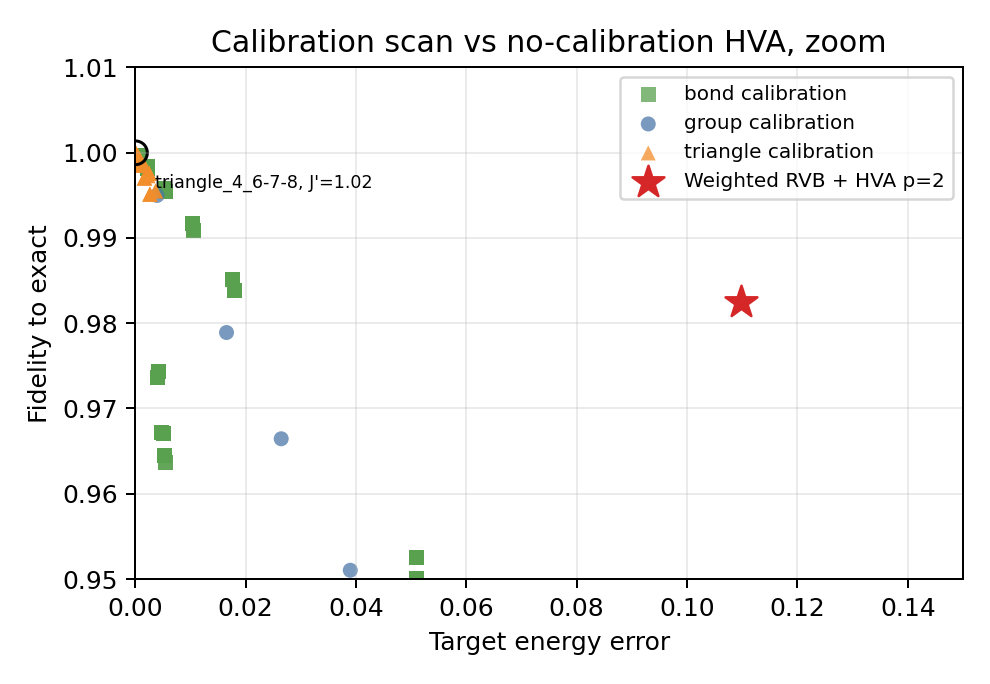

In [5]:
display(Image(filename=str(FIGURES / "calibration/calibration_energy_vs_fidelity.png")))
display(Image(filename=str(FIGURES / "calibration/calibration_energy_vs_fidelity_zoom.png")))

## Best No-Calibration HVA vs Best Calibrated Reference

This table separates the circuit-compatible no-calibration HVA baseline from the exact calibrated-Hamiltonian reference state.

In [6]:
comparison = pd.read_csv(RESULTS / "no_calibration_vs_best_calibration.csv")
comparison[["method", "type", "error_vs_exact", "fidelity", "circuit_preparable"]]

,method,type,error_vs_exact,fidelity,circuit_preparable
0,Weighted RVB + HVA p=4,no-calibration HVA baseline,0.108567,0.982518,refinement circuit yes; initializer classical
1,Best calibration: triangle_4_6-7-8,exact calibrated-Hamiltonian reference,0.000037,0.999966,not yet shown


## One-Page Summary Figure

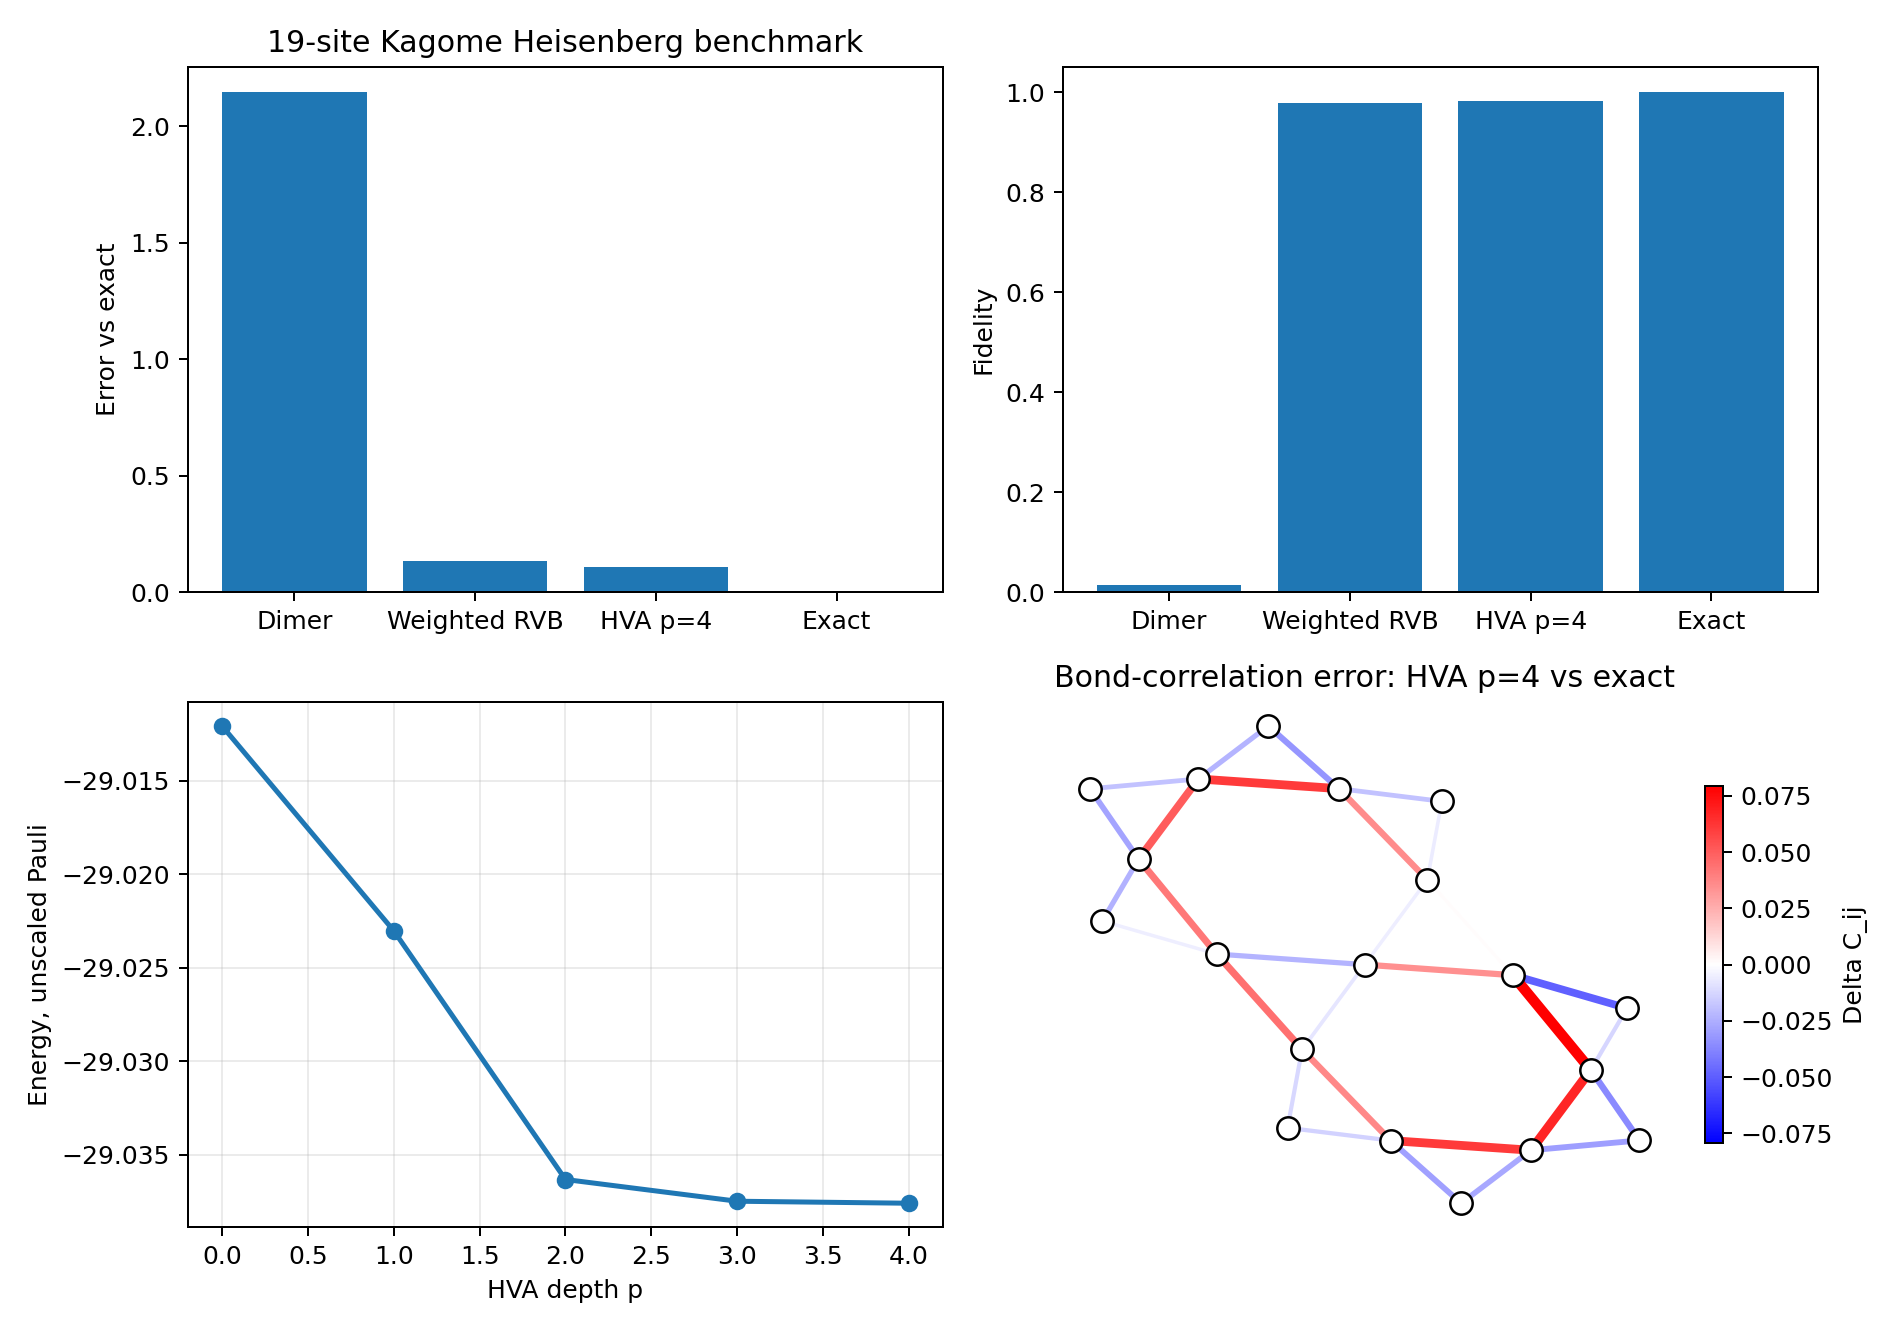

In [7]:
display(Image(filename=str(FIGURES / "summary/one_page_summary.png")))

## Interpretation

The weighted-RVB state is a classical variational/reference initializer from `H c = E S c`, not yet a hardware-preparable circuit. The edge-colored Heisenberg-HVA layers are circuit-compatible refinements. Calibration-scan states are exact ground states of modified Hamiltonians. Hardware-ready preparation is not yet shown.

The result is finite-size QSL-like evidence through energy, fidelity, magnetization, entanglement, and distributed bond-correlation diagnostics.

Limitations: this is a finite-size 19-site open-boundary patch in a fixed `Sz=1/2` sector; HVA improvement is currently modest and verified through `p=4`; the current no-calibration p=4 state is not yet competitive with the best small calibrated-Hamiltonian exact reference in energy or fidelity; no repeated-optimizer robustness campaign is included; no noise model or hardware execution is included; no scalable QSL preparation claim is made.